# Sweep results

Plots of `results/Pedestrian-sweep-*.json`, written by
`fit2082.boost.experiment`. Nothing here trains anything -- it reads the
committed result files, so it runs in a second and can be re-run after every
sweep.

The one rule the plots are built around: **only variants sharing a sweep are
directly comparable.** A "seed" is a rerun, not a reproducible draw (float32
scatter-adds on CUDA reorder the split ranking), and the baseline drifts by
more than most of the effects being measured. Every panel is therefore
grouped by sweep, and the paired comparison in §4 -- which cancels the drift
entirely -- is the one to lean on.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

RESULTS = Path("../results")
SWEEPS = sorted(RESULTS.glob("Pedestrian-sweep-*.json"))
REFERENCE = RESULTS / "Pedestrian-4eb8d6b.json"  # off-the-shelf models, same split

# results files sort alphabetically, which is not the order they were run in
ORDER_HINT = ["cac8e0b", "b21d3e8", "3d25491"]

[p.name for p in SWEEPS]

['Pedestrian-sweep-3d25491.json',
 'Pedestrian-sweep-b21d3e8.json',
 'Pedestrian-sweep-cac8e0b.json']

## Style

One hue per job: a single blue for "these are all the same measurement",
orange for the one point being emphasised, grey for context. The categorical
slots are only spent where the series really are separate identities.

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#8a8880"
GRID = "#e6e5e1"

BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
YELLOW = "#eda100"
MAGENTA = "#e87ba4"
VIOLET = "#4a3aa7"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, VIOLET]

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 9,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2.0,
        "figure.dpi": 120,
    }
)


def finish(ax, title=None, note=None, xlabel=None, ylabel=None):
    """Title, optional sub-note, recessive chrome."""

    if title:
        ax.set_title(title, pad=16 if note else 8)
    if note:
        ax.text(
            0.0,
            1.02,
            note,
            transform=ax.transAxes,
            fontsize=8.5,
            color=INK_2,
            va="bottom",
        )
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


def short(name: str) -> str:
    """Variant names are long; these are the same names, minus the boilerplate."""

    return (
        name.replace("readout_", "")
        .replace("adaptive_smooth_", "tau ")
        .replace("_bagged_4_capacity_2", " +bag4 +cap2")
        .replace("_bagged_4", " +bag4")
        .replace("_capacity_2", " +cap2")
    )

## Loading

Four tidy frames: one row per variant (`variants`), one per seed (`runs`),
one per evaluation point (`curves`) and one per readout optimiser step
(`history`). `sweep_id` is the comparability unit -- the file's commit, plus
the sweep number where the file records one.

In [3]:
def load_sweeps(paths):

    variants, runs, curves, history = [], [], [], []

    for path in paths:
        blob = json.loads(path.read_text())
        tag = path.stem.split("-")[-1]

        for name, entry in blob["models"].items():
            sweep = entry.get("sweep")
            sweep_id = f"{tag}/{sweep}" if sweep is not None else tag

            params = entry["params"]
            readout = params.get("readout") or {}

            variants.append(
                {
                    "sweep_id": sweep_id,
                    "file": path.name,
                    "commit": blob.get("commit"),
                    "variant": name,
                    "seeds": len(entry["runs"]),
                    "tau": params.get("shrinkage_tau"),
                    "shrinkage": params.get("neighbour_shrinkage"),
                    "estimators": params.get("estimators", 1),
                    "hashes_per_round": params.get("hashes_per_round", 1),
                    "rung": readout.get("rung"),
                    "mixed": bool(params.get("overrides")),
                    **entry["summary"],
                }
            )

            for run in entry["runs"]:
                info = run.get("readout")
                # sweeps before 3d25491 recorded neither of these
                boosted = run.get("boosted_final", run["final"])

                runs.append(
                    {
                        "sweep_id": sweep_id,
                        "variant": name,
                        "seed": run["seed"],
                        "final": run["final"],
                        "boosted_final": boosted,
                        # positive = the refit beat the boosted model it was given
                        "delta": boosted - run["final"],
                        "agreement": run.get("agreement"),
                        "rounds": run["rounds"],
                        "wall_s": run["wall_s"],
                        "peak_mb": run["peak_mb"],
                    }
                )

                x, y = run["curve"]["x"], run["curve"]["y"]
                for i, (xi, yi) in enumerate(zip(x, y)):
                    # a readout variant appends its refit score at the same x
                    # as the last boosted point; keep the two apart
                    last = i == len(x) - 1
                    curves.append(
                        {
                            "sweep_id": sweep_id,
                            "variant": name,
                            "seed": run["seed"],
                            "round": xi,
                            "error": yi,
                            "kind": "readout" if (last and info) else "boost",
                        }
                    )

                for step in (info or {}).get("history", []):
                    history.append(
                        {
                            "sweep_id": sweep_id,
                            "variant": name,
                            "seed": run["seed"],
                            "rung": info["rung"],
                            "rounds": info["rounds"],
                            "parameters": info["num_parameters"],
                            **step,
                        }
                    )

    return (
        pd.DataFrame(variants),
        pd.DataFrame(runs),
        pd.DataFrame(curves),
        pd.DataFrame(history),
    )


variants, runs, curves, history = load_sweeps(SWEEPS)


def sweep_key(sweep_id):
    tag, _, sweep = sweep_id.partition("/")
    order = ORDER_HINT.index(tag) if tag in ORDER_HINT else len(ORDER_HINT)
    return (order, tag, int(sweep) if sweep else 0)


SWEEP_ORDER = sorted(set(variants["sweep_id"]), key=sweep_key)
BASELINE = (
    variants[variants.variant == "baseline"].set_index("sweep_id")["mean"].to_dict()
)

reference = json.loads(REFERENCE.read_text())["models"]
XGB = min(reference["xgboost"]["results"]["va"]["merror"]["y"])
XGB_WALL = reference["xgboost"]["timings"][0]["wall_s"]

print(f"{len(variants)} variants over {len(SWEEP_ORDER)} sweeps: {SWEEP_ORDER}")
print(f"baselines: { {k: round(v, 4) for k, v in BASELINE.items()} }")
print(f"XGBoost reference: {XGB:.4f} in {XGB_WALL:.0f}s")

37 variants over 5 sweeps: ['cac8e0b', 'b21d3e8', '3d25491/2', '3d25491/3', '3d25491/4']
baselines: {'3d25491/2': 0.2214, 'cac8e0b': 0.224}
XGBoost reference: 0.2041 in 333s


### The table

Every variant, best first. `error` is validation error over the sweep's
seeds; `paired` is the mean per-seed gain of the readout refit over the very
model it was fit on, blank where a variant has no refit.

In [4]:
paired = runs.groupby(["sweep_id", "variant"])["delta"].agg(["mean", "std"])

table = variants.assign(
    paired=[
        (
            f"{paired.loc[(s, v), 'mean']:+.4f}"
            if abs(paired.loc[(s, v), "mean"]) > 1e-12
            else ""
        )
        for s, v in zip(variants.sweep_id, variants.variant)
    ],
    error=[f"{m:.4f} +- {s:.4f}" for m, s in zip(variants["mean"], variants["sd"])],
)[
    [
        "sweep_id",
        "variant",
        "error",
        "paired",
        "agreement",
        "rounds",
        "wall_s",
        "peak_mb",
        "seeds",
    ]
].sort_values("error")

table.reset_index(drop=True).style.format(
    {"agreement": "{:.3f}", "wall_s": "{:.0f}s", "peak_mb": "{:.0f}M"}, na_rep=""
).hide(axis="index")

sweep_id,variant,error,paired,agreement,rounds,wall_s,peak_mb,seeds
3d25491/3,readout_round_class_bagged_4_capacity_2,0.2006 +- 0.0025,+0.0049,0.906,1600,375s,5753M,3
3d25491/3,adaptive_smooth_3000_bagged_4_capacity_2,0.2023 +- 0.0017,,0.924,1600,308s,1854M,3
b21d3e8,smooth_0.3_bagged_4_capacity_2,0.2049 +- 0.0004,,,1600,305s,1851M,3
3d25491/2,adaptive_smooth_100_bagged_4_capacity_2,0.2052 +- 0.0012,,0.918,1600,311s,1854M,3
3d25491/2,bagged_4_capacity_2,0.2052 +- 0.0015,,0.905,1600,150s,1983M,3
3d25491/3,readout_table_bagged_4_capacity_2,0.2058 +- 0.0018,+0.0008,0.905,1600,1531s,8424M,3
b21d3e8,bagged_4_capacity_2,0.2059 +- 0.0017,,,1600,148s,1979M,3
3d25491/3,adaptive_smooth_3000_capacity_2,0.2062 +- 0.0023,,,1600,78s,643M,3
3d25491/2,adaptive_smooth_100_capacity_2,0.2072 +- 0.0018,,,1600,78s,643M,3
3d25491/3,capacity_2,0.2109 +- 0.0020,,,1600,37s,771M,3


## 1. The noise floor

Four configurations were measured in more than one sweep. Each row is one of
them: the dots are that sweep's mean, the faint dots its individual runs. If
the same configuration moves by more between sweeps than most variants differ
from each other, then seeds are measuring repeatability and not much else --
and an unpaired difference smaller than that spread is unreadable.

`torch.manual_seed` does not fix this. Float32 scatter-adds on CUDA
accumulate in nondeterministic order, that perturbs the logits, the perturbed
logits reorder the cross-entropy ranking in `HardPairSplitter`, and every
hash chosen after that point differs. A "seed" here is just a rerun.

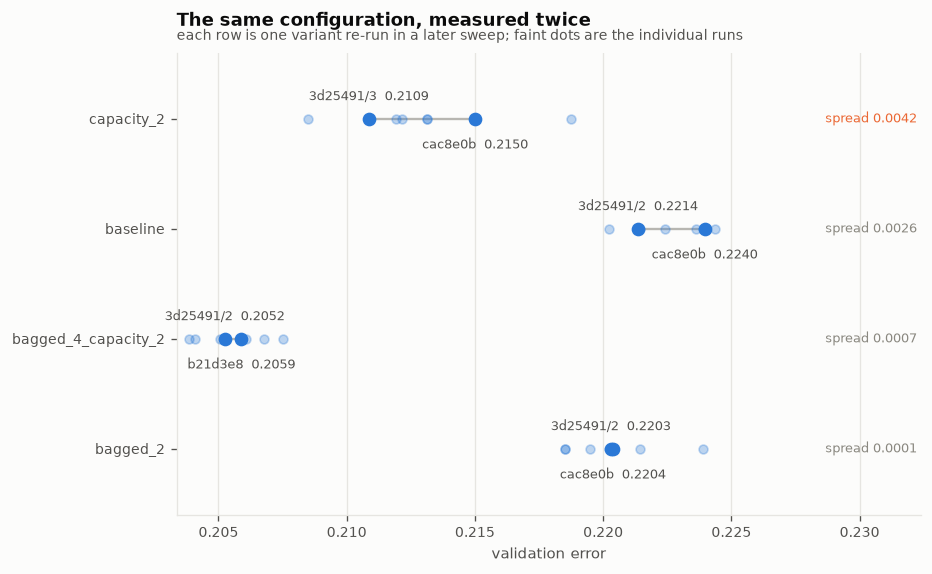

In [5]:
counts = variants.groupby("variant")["sweep_id"].transform("size")
repeats = variants[counts > 1].copy()
repeats["spread"] = repeats.groupby("variant")["mean"].transform(
    lambda g: g.max() - g.min()
)
rows = (
    repeats.groupby("variant")["spread"]
    .first()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(8.0, 0.85 * len(rows) + 1.6))

for i, name in enumerate(rows):
    g = repeats[repeats.variant == name].sort_values("mean")
    ax.plot(
        [g["mean"].min(), g["mean"].max()],
        [i, i],
        color=MUTED,
        lw=1.4,
        alpha=0.6,
        zorder=2,
    )

    seeds = runs[(runs.variant == name) & runs.sweep_id.isin(g["sweep_id"])]
    ax.scatter(
        seeds["final"], np.full(len(seeds), i), s=28, color=BLUE, alpha=0.3, zorder=3
    )
    ax.scatter(g["mean"], np.full(len(g), i), s=52, color=BLUE, zorder=4)

    for j, (_, r) in enumerate(g.iterrows()):
        ax.annotate(
            f"{r['sweep_id']}  {r['mean']:.4f}",
            (r["mean"], i),
            textcoords="offset points",
            xytext=(0, 11 if j % 2 == 0 else -18),
            ha="center",
            fontsize=7.5,
            color=INK_2,
        )

    ax.annotate(
        f"spread {g['spread'].iloc[0]:.4f}",
        (0.995, i),
        xycoords=("axes fraction", "data"),
        ha="right",
        va="center",
        fontsize=8,
        color=ORANGE if g["spread"].iloc[0] > 0.003 else MUTED,
    )

lo, hi = repeats["mean"].min(), repeats["mean"].max()
ax.set_xlim(lo - 0.1 * (hi - lo), hi + 0.45 * (hi - lo))
ax.set_yticks(range(len(rows)), rows, fontsize=8.5)
ax.set_ylim(-0.6, len(rows) - 0.4)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)

finish(
    ax,
    "The same configuration, measured twice",
    "each row is one variant re-run in a later sweep; faint dots are the "
    "individual runs",
    xlabel="validation error",
)
plt.show()

## 2. Every variant, grouped by sweep

One panel per sweep, because that is the boundary within which a comparison
means anything. The grey rule is that sweep's own baseline where it ran one;
the dashed rule is XGBoost on the same split. Orange is the best variant in
the panel. Points past the right edge are drawn as arrows carrying their
value.

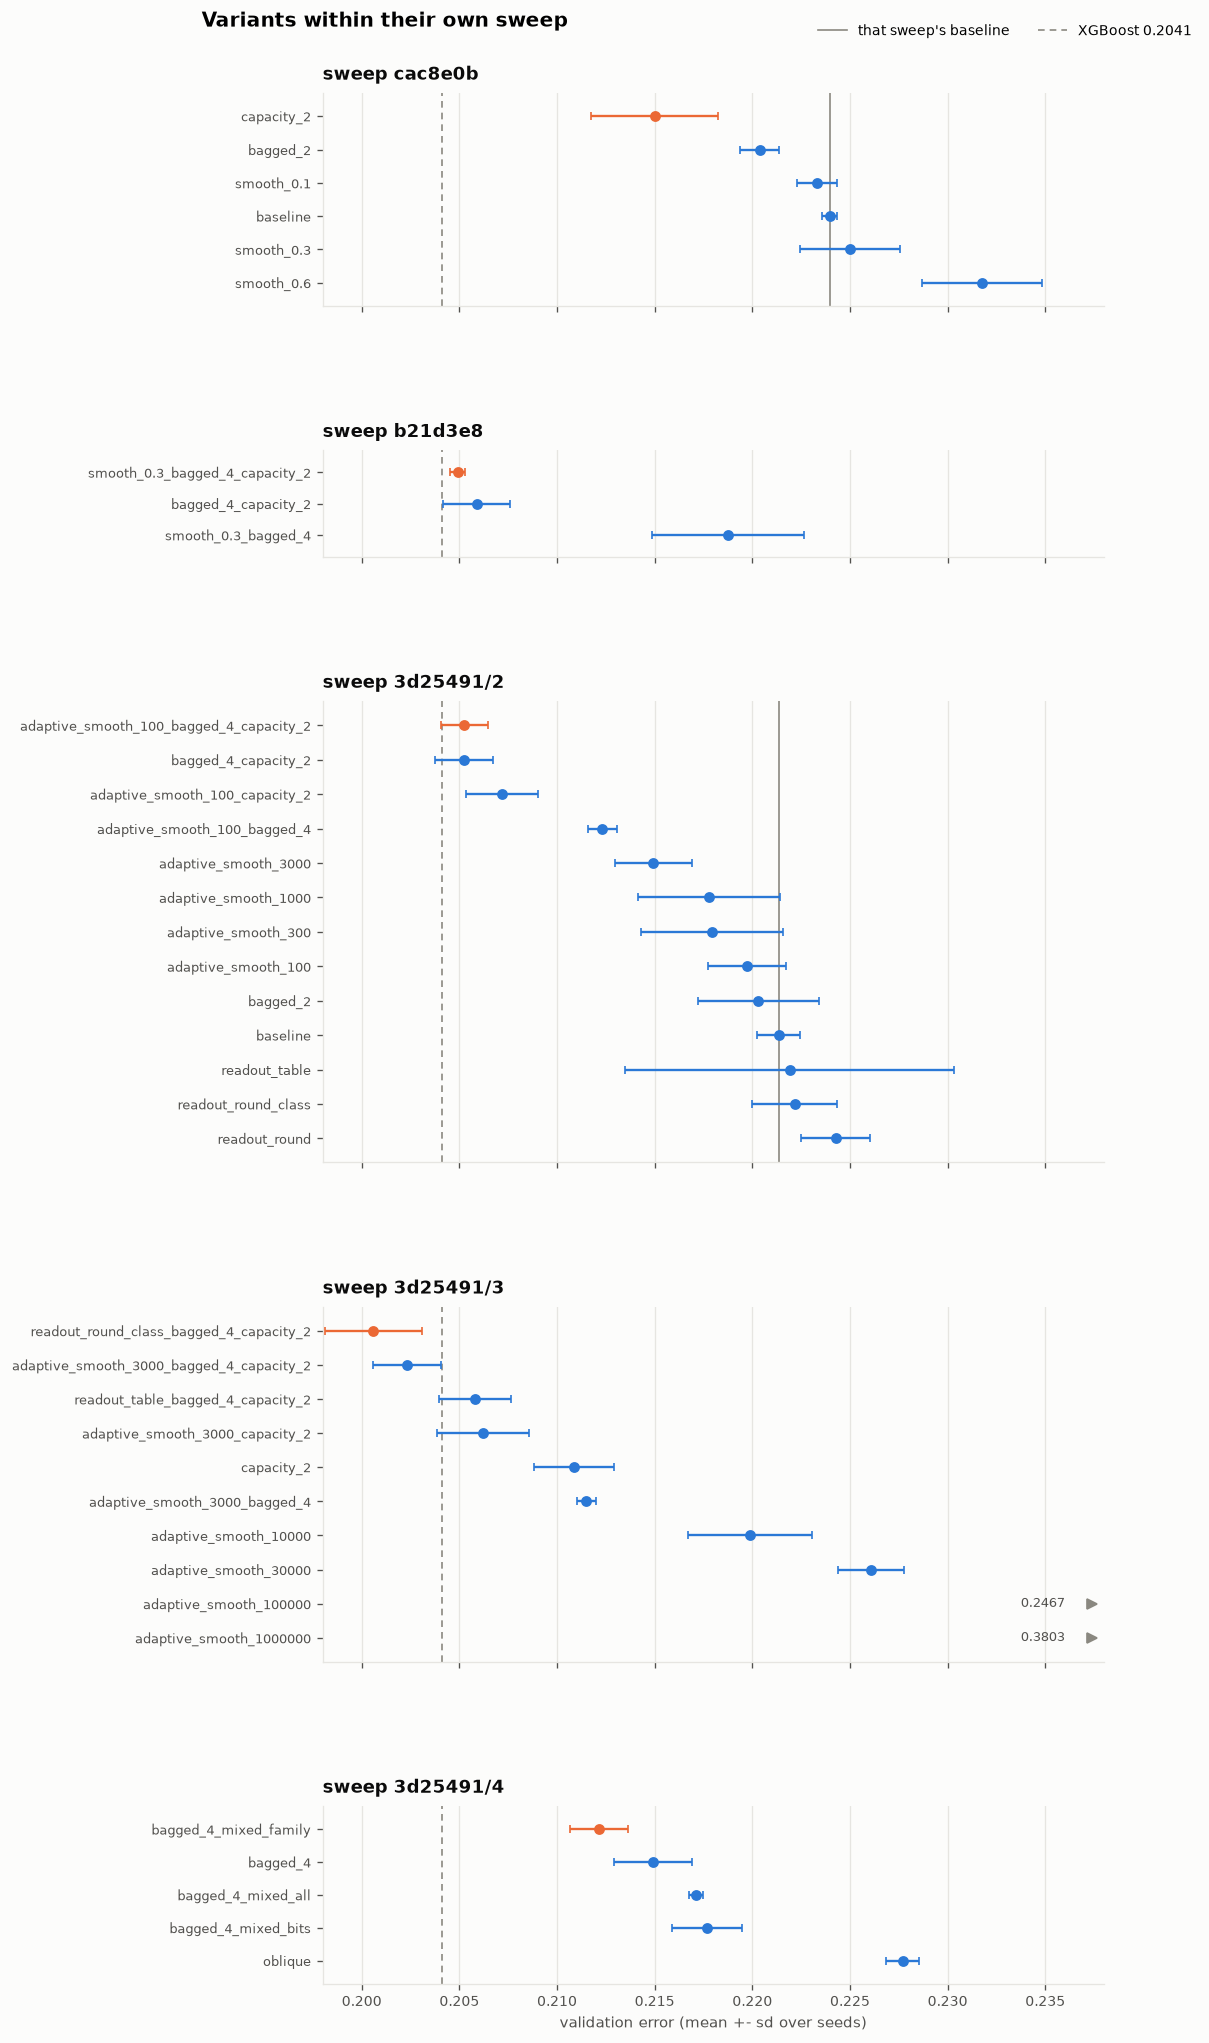

In [6]:
XMIN, XMAX = 0.198, 0.238

groups = [
    (s, variants[variants.sweep_id == s].sort_values("mean")) for s in SWEEP_ORDER
]
heights = [len(g) for _, g in groups]

fig, axes = plt.subplots(
    len(groups),
    1,
    figsize=(8.4, 0.30 * sum(heights) + 1.5 * len(groups)),
    sharex=True,
    gridspec_kw={"height_ratios": heights, "hspace": 0.55},
)
axes = np.atleast_1d(axes)

for ax, (sweep_id, g) in zip(axes, groups):
    y = np.arange(len(g))
    best = int(np.argmin(g["mean"].to_numpy()))
    inside = g["mean"].to_numpy() <= XMAX

    ax.axvline(XGB, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
    if sweep_id in BASELINE:
        ax.axvline(BASELINE[sweep_id], color=MUTED, lw=1.0, zorder=1)

    for i, (m, s) in enumerate(zip(g["mean"], g["sd"])):
        if inside[i]:
            ax.errorbar(
                m,
                i,
                xerr=s,
                fmt="o",
                ms=5.5,
                color=ORANGE if i == best else BLUE,
                ecolor=ORANGE if i == best else BLUE,
                elinewidth=1.4,
                capsize=2.5,
                zorder=3,
            )
        else:
            ax.plot(XMAX - 0.0006, i, marker=">", ms=6, color=MUTED, clip_on=False)
            ax.annotate(
                f"{m:.4f}",
                (XMAX - 0.002, i),
                ha="right",
                va="center",
                fontsize=7.5,
                color=INK_2,
            )

    ax.set_yticks(y, g["variant"], fontsize=7.5)
    ax.set_ylim(-0.7, len(g) - 0.3)
    ax.invert_yaxis()
    ax.set_xlim(XMIN, XMAX)
    ax.grid(axis="y", visible=False)
    finish(ax, f"sweep {sweep_id}")

axes[-1].set_xlabel("validation error (mean +- sd over seeds)")

height = fig.get_figheight()
fig.subplots_adjust(top=1 - 0.8 / height)
fig.suptitle(
    "Variants within their own sweep",
    x=0.005,
    y=1 - 0.12 / height,
    ha="left",
    va="top",
    fontsize=12,
    weight="bold",
)
fig.legend(
    handles=[
        Line2D([], [], color=MUTED, lw=1, label="that sweep's baseline"),
        Line2D([], [], color=MUTED, lw=1, ls=(0, (4, 3)), label=f"XGBoost {XGB:.4f}"),
    ],
    loc="upper right",
    bbox_to_anchor=(1.0, 1 - 0.12 / height),
    ncols=2,
)
plt.show()

## 3. Learning curves

Validation error against boosting rounds, averaged over seeds with the
seed-to-seed range as a band. Evaluation runs every 10 epochs, so these are
five points, not a smooth curve, and the first one is usually off the top of
this scale. Where a variant carries a readout refit, the refit lands at the
same round as the last boosted point and is drawn as a separate ring.

Rounds, not wall time, is the x axis here -- §6 is the same story against
cost.

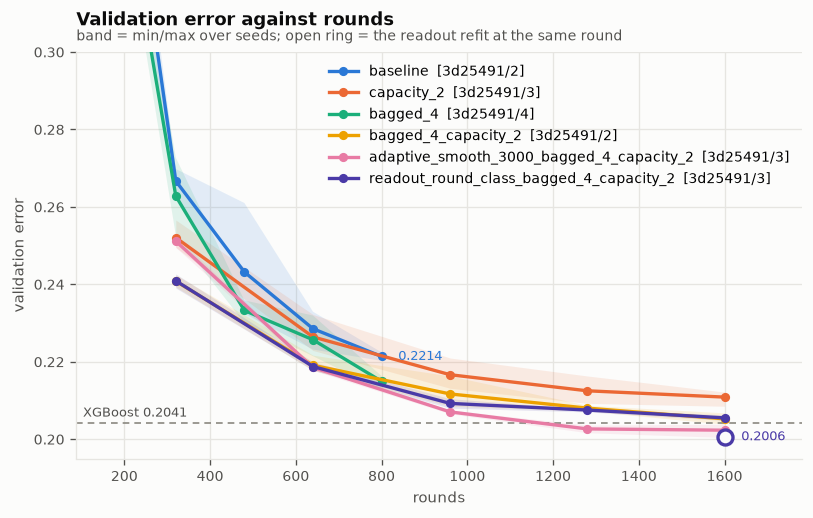

In [7]:
TRACKED = [
    "baseline",
    "capacity_2",
    "bagged_4",
    "bagged_4_capacity_2",
    "adaptive_smooth_3000_bagged_4_capacity_2",
    "readout_round_class_bagged_4_capacity_2",
]
LABELLED = {"baseline", "readout_round_class_bagged_4_capacity_2"}

fig, ax = plt.subplots(figsize=(7.8, 4.4))

for color, name in zip(SERIES, TRACKED):
    sub = curves[(curves.variant == name) & (curves.kind == "boost")]
    if sub.empty:
        continue
    sweep_id = sub["sweep_id"].iloc[0]
    sub = sub[sub.sweep_id == sweep_id]

    stats = sub.groupby("round")["error"].agg(["mean", "min", "max"])
    ax.fill_between(
        stats.index, stats["min"], stats["max"], color=color, alpha=0.12, lw=0
    )
    ax.plot(
        stats.index,
        stats["mean"],
        color=color,
        marker="o",
        ms=4.5,
        label=f"{name}  [{sweep_id}]",
    )

    end_x, end_y = stats.index[-1], stats["mean"].iloc[-1]

    refit = curves[(curves.variant == name) & (curves.kind == "readout")]
    if not refit.empty:
        r = refit[refit.sweep_id == sweep_id].groupby("round")["error"].mean()
        ax.plot(
            r.index,
            r.values,
            marker="o",
            ms=9,
            mfc=SURFACE,
            mec=color,
            mew=2,
            ls="none",
            zorder=4,
        )
        end_x, end_y = r.index[-1], r.iloc[-1]

    if name in LABELLED:
        ax.annotate(
            f"{end_y:.4f}",
            (end_x, end_y),
            textcoords="offset points",
            xytext=(10, 0),
            fontsize=8,
            color=color,
            va="center",
        )

ax.axhline(XGB, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.annotate(
    f"XGBoost {XGB:.4f}",
    (ax.get_xlim()[0], XGB),
    textcoords="offset points",
    xytext=(4, 4),
    fontsize=8,
    color=INK_2,
)

ax.set_ylim(0.195, 0.30)
ax.set_xlim(right=1780)
ax.legend(loc="upper right")
finish(
    ax,
    "Validation error against rounds",
    "band = min/max over seeds; open ring = the readout refit at the same round",
    xlabel="rounds",
    ylabel="validation error",
)
plt.show()

## 4. The readout refit, paired

The refit does not change training, so it can be scored against the very same
fitted model rather than against a different run. Each grey line is one seed's
boosted error and its refit error; the bars are the mean gain. This is the
comparison that is immune to the drift in §1 -- the `table` rung on a plain
800-round model moves every seed by nearly the same amount, so its paired sd
is 0.0002 where the unpaired sd over those same three runs is 0.0084.

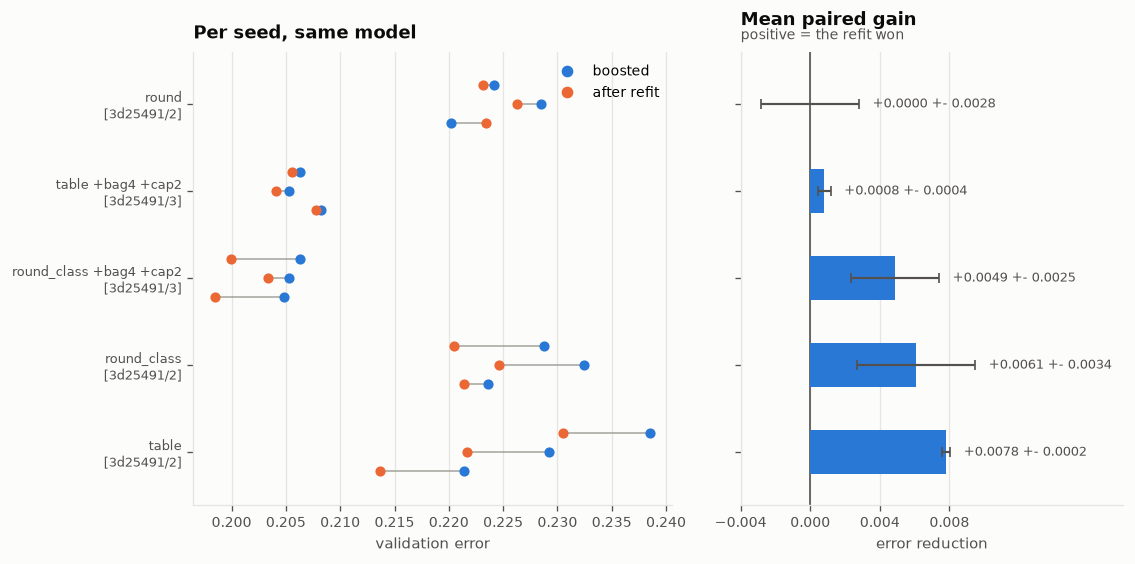

In [8]:
refits = runs[runs["delta"].abs() > 1e-12].copy()
names = (
    refits.groupby(["sweep_id", "variant"])["delta"].mean().sort_values().index.tolist()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.0, 0.62 * len(names) + 1.8),
    sharey=True,
    gridspec_kw={"width_ratios": [1.25, 1], "wspace": 0.16},
)

# left: one dumbbell per seed, boosted -> refit
ax = axes[0]
offsets = np.linspace(-0.22, 0.22, refits.groupby(["sweep_id", "variant"]).size().max())

for i, (sweep_id, name) in enumerate(names):
    sub = refits[(refits.sweep_id == sweep_id) & (refits.variant == name)]
    for off, (_, r) in zip(offsets, sub.iterrows()):
        ax.plot(
            [r["boosted_final"], r["final"]],
            [i + off, i + off],
            color=MUTED,
            lw=1.0,
            alpha=0.7,
            zorder=2,
        )
        ax.scatter(r["boosted_final"], i + off, s=26, color=BLUE, zorder=3)
        ax.scatter(r["final"], i + off, s=26, color=ORANGE, zorder=3)

ax.set_yticks(range(len(names)), [f"{short(v)}\n[{s}]" for s, v in names], fontsize=7.5)
ax.set_ylim(-0.6, len(names) - 0.4)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Line2D([], [], marker="o", ls="none", color=BLUE, label="boosted"),
        Line2D([], [], marker="o", ls="none", color=ORANGE, label="after refit"),
    ],
    loc="upper right",
)
finish(ax, "Per seed, same model", xlabel="validation error")

# right: mean paired gain
ax = axes[1]
stats = refits.groupby(["sweep_id", "variant"])["delta"].agg(["mean", "std"]).loc[names]
err = stats["std"].fillna(0)
y = np.arange(len(names))

ax.barh(y, stats["mean"], height=0.5, color=BLUE, zorder=2)
ax.errorbar(
    stats["mean"],
    y,
    xerr=err,
    fmt="none",
    ecolor=INK_2,
    elinewidth=1.3,
    capsize=3,
    zorder=3,
)
ax.axvline(0, color=INK_2, lw=1.0, zorder=1)

for i, (m, s) in enumerate(zip(stats["mean"], err)):
    ax.annotate(
        f"{m:+.4f} +- {s:.4f}",
        (max(m + s, 0), i),
        textcoords="offset points",
        xytext=(8, 0),
        ha="left",
        va="center",
        fontsize=8,
        color=INK_2,
    )

ax.set_xlim(-0.004, 0.018)
ax.set_xticks([-0.004, 0.0, 0.004, 0.008])
ax.grid(axis="y", visible=False)
finish(ax, "Mean paired gain", "positive = the refit won", xlabel="error reduction")
plt.show()

## 5. Mass-adaptive smoothing

`alpha_s = tau / (tau + mass_s)`: tau is the bucket mass at which a bucket
trusts itself and its neighbours equally. Typical bucket mass here is ~1e4
(65,536 rows x 50 epochs / 256 buckets), so the interior optimum should sit
an order of magnitude below that -- and does. An inverted U is a shape
baseline drift cannot manufacture, which is why this reads as a real effect
where the single-point comparisons elsewhere do not.

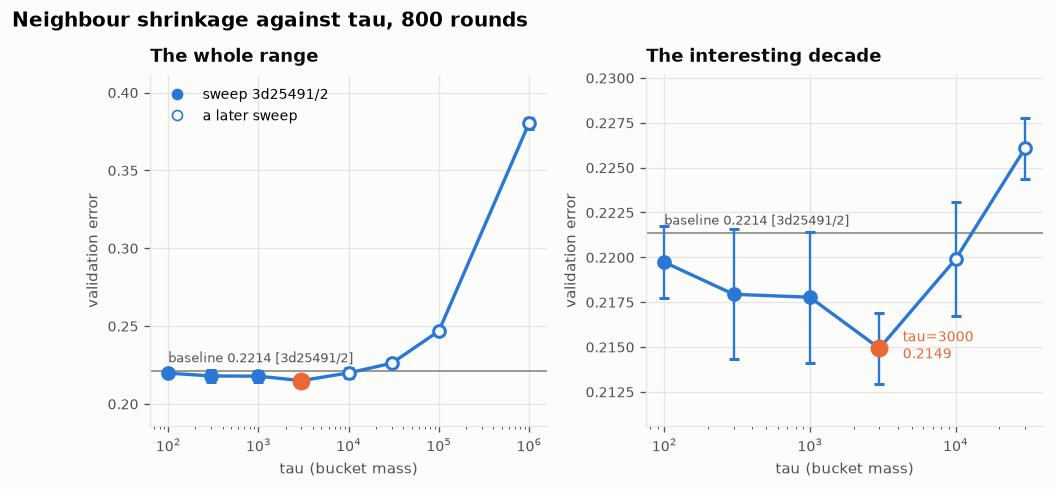

In [9]:
taus = variants[
    variants["tau"].notna()
    & (variants.estimators == 1)
    & (variants.hashes_per_round == 1)
].sort_values("tau")

first = taus["sweep_id"].iloc[0]
zoom = taus[taus["tau"] <= 30_000]

fig, axes = plt.subplots(
    1, 2, figsize=(9.6, 3.8), gridspec_kw={"width_ratios": [1, 1], "wspace": 0.25}
)

for ax, data, title in (
    (axes[0], taus, "The whole range"),
    (axes[1], zoom, "The interesting decade"),
):
    ax.plot(data["tau"], data["mean"], color=BLUE, zorder=2)
    for _, r in data.iterrows():
        same = r["sweep_id"] == first
        ax.errorbar(
            r["tau"],
            r["mean"],
            yerr=r["sd"],
            fmt="o",
            ms=7,
            color=BLUE,
            mfc=BLUE if same else SURFACE,
            mew=1.8,
            ecolor=BLUE,
            elinewidth=1.4,
            capsize=3,
            zorder=3,
        )

    best = data.loc[data["mean"].idxmin()]
    ax.scatter(best["tau"], best["mean"], s=95, color=ORANGE, zorder=4)
    if data is zoom:  # the callout would sit on the baseline rule in the wide view
        ax.annotate(
            f"tau={best['tau']:.0f}\n{best['mean']:.4f}",
            (best["tau"], best["mean"]),
            textcoords="offset points",
            xytext=(14, -6),
            ha="left",
            fontsize=8.5,
            color=ORANGE,
        )

    if first in BASELINE:
        ax.axhline(BASELINE[first], color=MUTED, lw=1.0, zorder=1)
        ax.annotate(
            f"baseline {BASELINE[first]:.4f} [{first}]",
            (data["tau"].min(), BASELINE[first]),
            textcoords="offset points",
            xytext=(0, 5),
            fontsize=8,
            color=INK_2,
        )

    ax.set_xscale("log")
    ax.margins(y=0.16)
    finish(ax, title, xlabel="tau (bucket mass)", ylabel="validation error")

axes[0].legend(
    handles=[
        Line2D([], [], marker="o", ls="none", color=BLUE, label=f"sweep {first}"),
        Line2D(
            [],
            [],
            marker="o",
            ls="none",
            color=BLUE,
            mfc=SURFACE,
            label="a later sweep",
        ),
    ],
    loc="upper left",
)
fig.suptitle(
    "Neighbour shrinkage against tau, 800 rounds",
    x=0.005,
    y=1.02,
    ha="left",
    fontsize=12,
    weight="bold",
)
plt.show()

## 6. What the accuracy costs

Wall time against error, one point per variant (a variant measured in two
sweeps keeps its better number, so read levels here as approximate -- the
frontier's *shape* is the point). Cost is quadratic in rounds, so the useful
question is not which variant wins but which ones are on the frontier at all.
XGBoost on the same split is the diamond; it is CPU time against these GPU
runs, so it is a reference, not a race.

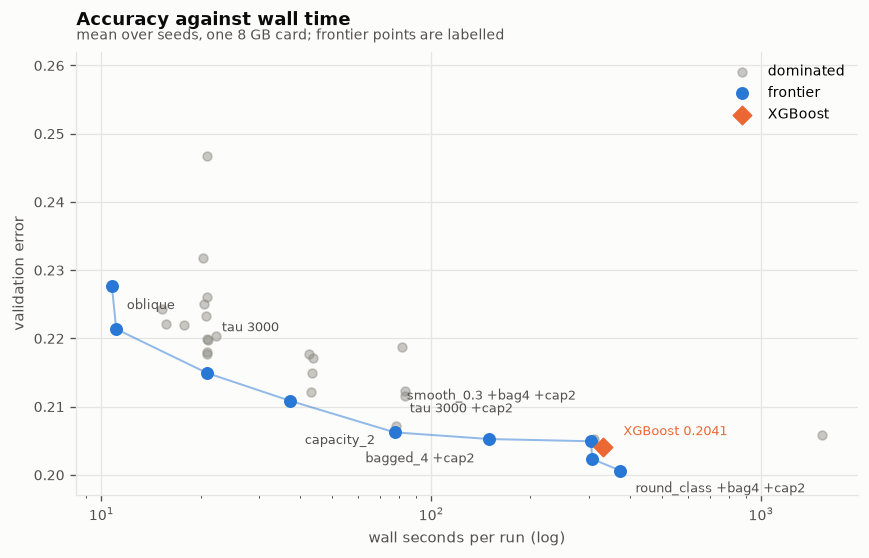

In [10]:
pts = (
    variants.sort_values("mean")
    .drop_duplicates("variant")
    .sort_values("wall_s")
    .reset_index(drop=True)
)

front, best_so_far = [], np.inf
for _, r in pts.iterrows():
    if r["mean"] < best_so_far:
        best_so_far = r["mean"]
        front.append(r["variant"])

on = pts["variant"].isin(front)

fig, ax = plt.subplots(figsize=(8.4, 4.8))

ax.scatter(
    pts.loc[~on, "wall_s"],
    pts.loc[~on, "mean"],
    s=28,
    color=MUTED,
    alpha=0.45,
    zorder=2,
    label="dominated",
)
ax.plot(
    pts.loc[on, "wall_s"], pts.loc[on, "mean"], color=BLUE, lw=1.2, alpha=0.5, zorder=2
)
ax.scatter(
    pts.loc[on, "wall_s"],
    pts.loc[on, "mean"],
    s=46,
    color=BLUE,
    zorder=3,
    label="frontier",
)
ax.scatter([XGB_WALL], [XGB], marker="D", s=60, color=ORANGE, zorder=4, label="XGBoost")

# alternate the labels above and below the frontier so neighbours never share a
# horizontal band, and turn them inward once past the middle of the axis
mid = np.sqrt(pts["wall_s"].min() * pts["wall_s"].max())
frontier = pts[on].reset_index(drop=True)
last, k = -np.inf, 0

for j, r in frontier.iterrows():
    # frontier points bunch up at the expensive end; label one per ~0.13 of a
    # decade, and always the cheapest and the best
    if not (np.log10(r["wall_s"]) - last > 0.13 or j in (0, len(frontier) - 1)):
        continue
    last, k = np.log10(r["wall_s"]), k + 1
    # the best point has empty space to its right; everything else points
    # inward, cycling through four vertical bands so labels cannot stack
    end = j == len(frontier) - 1
    right = r["wall_s"] > mid and not end
    ax.annotate(
        short(r["variant"]),
        (r["wall_s"], r["mean"]),
        textcoords="offset points",
        xytext=(-9 if right else 9, -13 if end else [12, -14, 25, -26][k % 4]),
        ha="right" if right else "left",
        fontsize=7.5,
        color=INK_2,
    )

ax.annotate(
    f"XGBoost {XGB:.4f}",
    (XGB_WALL, XGB),
    textcoords="offset points",
    xytext=(12, 7),
    ha="left",
    fontsize=8,
    color=ORANGE,
)

ax.set_xscale("log")
ax.set_ylim(0.197, 0.262)
ax.legend(loc="upper right")
finish(
    ax,
    "Accuracy against wall time",
    "mean over seeds, one 8 GB card; frontier points are labelled",
    xlabel="wall seconds per run (log)",
    ylabel="validation error",
)
plt.show()

## 7. Does decorrelating the members pay?

`estimator_agreement` is how often two bagged members pick the same class --
the mechanism heterogeneous bagging is supposed to move, and one the +-0.003
noise floor makes hard to read from the error alone. Every mixture
decorrelates; only the family mix converts that into accuracy. Smoothing
pushes agreement the other way, because part of what decorrelates the members
is exactly the empty-bucket noise it removes. Labels are selective; the table
above has the rest.

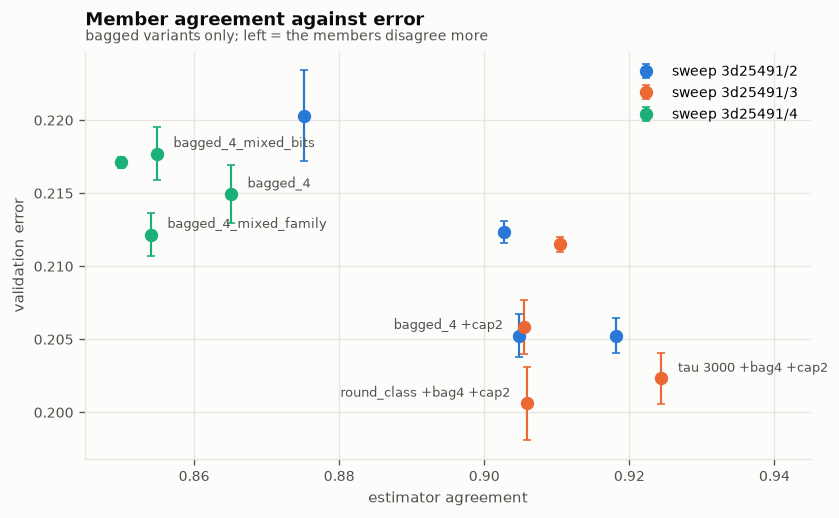

In [11]:
bagged = variants[variants["agreement"].notna()].copy()
CALLOUTS = {
    "bagged_4",
    "bagged_4_mixed_family",
    "bagged_4_mixed_bits",
    "bagged_4_capacity_2",
    "adaptive_smooth_3000_bagged_4_capacity_2",
    "readout_round_class_bagged_4_capacity_2",
}

fig, ax = plt.subplots(figsize=(7.8, 4.4))

for i, sweep_id in enumerate([s for s in SWEEP_ORDER if s in set(bagged.sweep_id)]):
    g = bagged[bagged.sweep_id == sweep_id]
    ax.errorbar(
        g["agreement"],
        g["mean"],
        yerr=g["sd"],
        fmt="o",
        ms=7,
        color=SERIES[i % len(SERIES)],
        ecolor=SERIES[i % len(SERIES)],
        elinewidth=1.3,
        capsize=2.5,
        label=f"sweep {sweep_id}",
        zorder=3,
    )

for _, r in bagged[bagged.variant.isin(CALLOUTS)].iterrows():
    # point inward, except at the two ends where there is room outside
    right = bagged["agreement"].median() < r["agreement"] < bagged["agreement"].max()
    ax.annotate(
        short(r["variant"]),
        (r["agreement"], r["mean"]),
        textcoords="offset points",
        xytext=(-10 if right else 10, 4),
        ha="right" if right else "left",
        fontsize=7.5,
        color=INK_2,
    )

ax.set_xlim(0.845, 0.945)
ax.legend(loc="upper right")
finish(
    ax,
    "Member agreement against error",
    "bagged variants only; left = the members disagree more",
    xlabel="estimator agreement",
    ylabel="validation error",
)
plt.show()

## 8. Is the refit actually training?

Tune-slice error against Adam step, per rung, seed 0. The `table` rung on the
6400-round ensemble is 134M parameters warm-started at the boosted solution:
a flat line there does not mean the rung lost, it means 300 steps at lr=0.01
is not enough optimisation when each parameter only sees gradient from the
handful of examples landing in its bucket. Early stopping keeps the best step
and starts at the warm start, so a flat line costs wall time and nothing else.

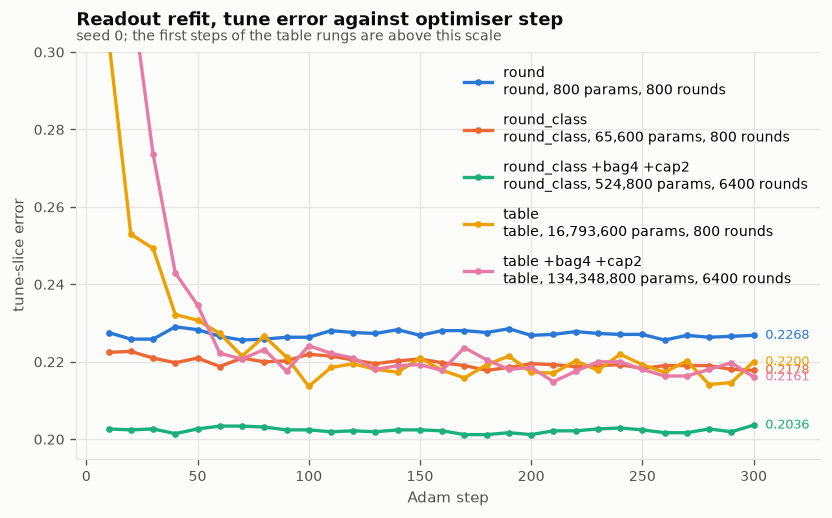

In [12]:
if not history.empty:
    seed0 = history[history.seed == history.seed.min()]
    order = seed0.groupby("variant")["parameters"].first().sort_values().index

    fig, ax = plt.subplots(figsize=(8.0, 4.4))

    for color, name in zip(SERIES, order):
        sub = seed0[seed0.variant == name]
        info = sub.iloc[0]
        ax.plot(
            sub["step"],
            sub["tune"],
            color=color,
            marker="o",
            ms=3,
            label=(
                f"{short(name)}\n{info['rung']}, {info['parameters']:,} params, "
                f"{info['rounds']} rounds"
            ),
        )
        ax.annotate(
            f"{sub['tune'].iloc[-1]:.4f}",
            (sub["step"].iloc[-1], sub["tune"].iloc[-1]),
            textcoords="offset points",
            xytext=(7, 0),
            fontsize=8,
            color=color,
            va="center",
        )

    ax.set_ylim(0.195, 0.30)
    ax.set_xlim(right=330)
    ax.legend(loc="upper right", labelspacing=0.9)
    finish(
        ax,
        "Readout refit, tune error against optimiser step",
        "seed 0; the first steps of the table rungs are above this scale",
        xlabel="Adam step",
        ylabel="tune-slice error",
    )
    plt.show()